# Clustering pas à pas

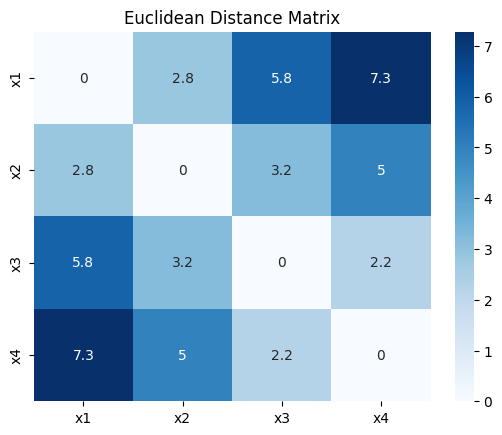

Distance Matrix:
 [[0.         2.82842712 5.83095189 7.28010989]
 [2.82842712 0.         3.16227766 5.        ]
 [5.83095189 3.16227766 0.         2.23606798]
 [7.28010989 5.         2.23606798 0.        ]]
Squared Distance Matrix:
 [[ 0.  8. 34. 53.]
 [ 8.  0. 10. 25.]
 [34. 10.  0.  5.]
 [53. 25.  5.  0.]]
Ward Jumps Matrix:
 [[0.    1.    4.25  6.625]
 [1.    0.    1.25  3.125]
 [4.25  1.25  0.    0.625]
 [6.625 3.125 0.625 0.   ]]
Smallest Inter-inertia Loss (pertemin1): 0.0


In [1]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
import seaborn as sns

# Data matrix
A = np.array([[2, 12], [4, 10], [5, 7], [4, 5]])
X = pd.DataFrame(A, columns=["var1", "var2"], index=["x1", "x2", "x3", "x4"])

# Euclidean distance
dist_matrix = squareform(pdist(X, metric="euclidean"))

# Square distances
dist_squared = dist_matrix ** 2

# The matrix of ward jumps with distance squared
ward1 = dist_squared / 8

# The smallest inter-inertia loss
pertemin1 = np.min(ward1)

# Visualize distance matrix using heatmap
sns.heatmap(dist_matrix, annot=True, cmap="Blues", cbar=True, xticklabels=X.index, yticklabels=X.index)
plt.title("Euclidean Distance Matrix")
plt.show()

# Output results
print("Distance Matrix:\n", dist_matrix)
print("Squared Distance Matrix:\n", dist_squared)
print("Ward Jumps Matrix:\n", ward1)
print("Smallest Inter-inertia Loss (pertemin1):", pertemin1)


In [2]:
# Data matrix
A = np.array([[2, 12], [4, 10], [4.5, 6]])
X = pd.DataFrame(A, columns=["var1", "var2"], index=["x1", "x2", "g34"])

# Euclidean distance
dist_matrix = squareform(pdist(X, metric="euclidean"))

# Square distances
dist_squared = dist_matrix ** 2

# The smallest loss ontlyb x1 and x2
min_loss = np.min(dist_squared) * (1 / 8)

# Output results
print("Distance Matrix:\n", dist_matrix)
print("Squared Distance Matrix:\n", dist_squared)
print("Smallest Loss (min_loss):", min_loss)


Distance Matrix:
 [[0.         2.82842712 6.5       ]
 [2.82842712 0.         4.03112887]
 [6.5        4.03112887 0.        ]]
Squared Distance Matrix:
 [[ 0.    8.   42.25]
 [ 8.    0.   16.25]
 [42.25 16.25  0.  ]]
Smallest Loss (min_loss): 0.0


Cluster labels:
 [2 3 1 0]


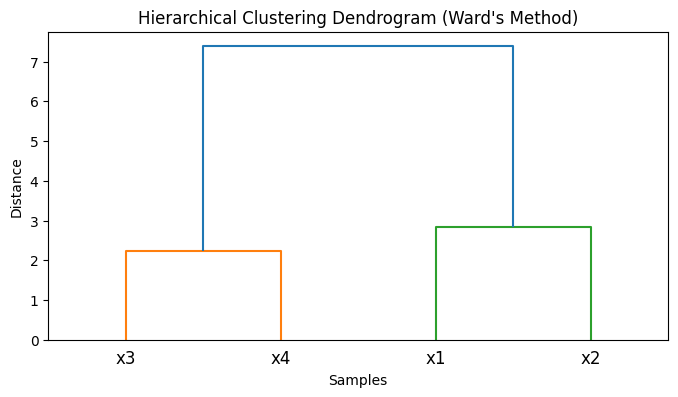

In [3]:
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Data matrix
A = np.array([[2, 12], [4, 10], [5, 7], [4, 5]])
X = pd.DataFrame(A, columns=["var1", "var2"], index=["x1", "x2", "x3", "x4"])

# Hierarchical clustering using Ward's method
linked = linkage(X, method='ward')

# Fit the hierarchical clustering
model = AgglomerativeClustering(n_clusters=None, distance_threshold=0).fit(X)

# Output: Cluster labels
print("Cluster labels:\n", model.labels_)

# Visualization: Dendrogram
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(8, 4))
dendrogram(linked, labels=X.index, distance_sort='ascending', show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram (Ward's Method)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


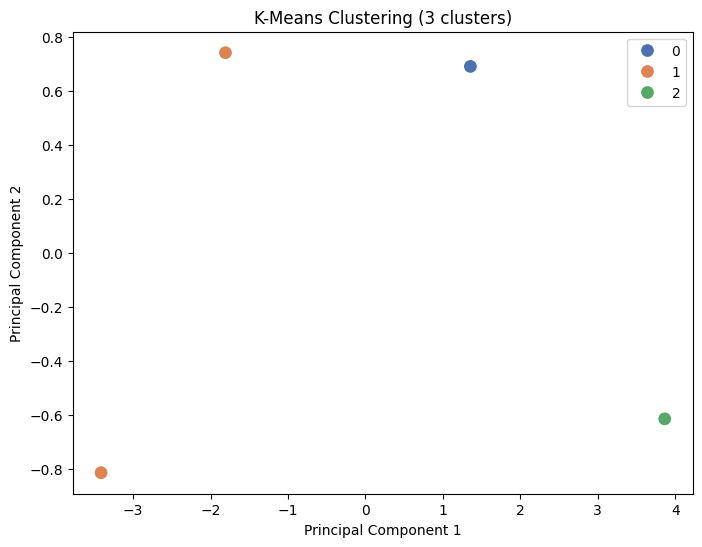

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns

# Apply PCA to reduce dimensionality (optional for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# K-Means clustering with 3 clusters (equivalent to nb.clust=3)
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_pca)

# Visualize clustering result using a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette="deep", s=100)
plt.title("K-Means Clustering (3 clusters)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()
